# Customer Segmentation Using K-Means Clustering

## Objective
To group customers based on spending behavior and annual income.

## Techniques Used
- Exploratory Data Analysis (EDA)
- K-Means Clustering
- PCA Visualization

## Goal
Identify customer segments and suggest marketing strategies.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

(200, 5)

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

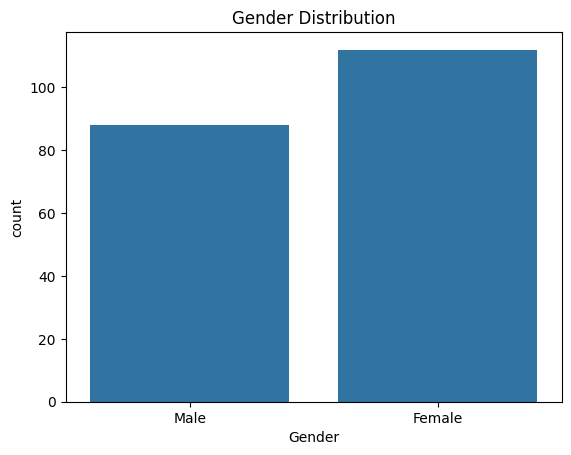

In [8]:
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

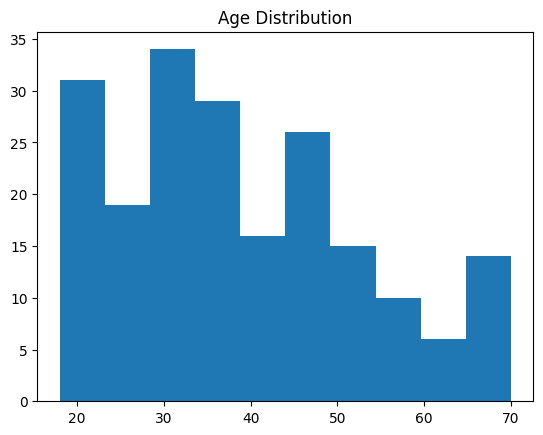

In [9]:
plt.hist(df["Age"])

plt.title("Age Distribution")

plt.show()

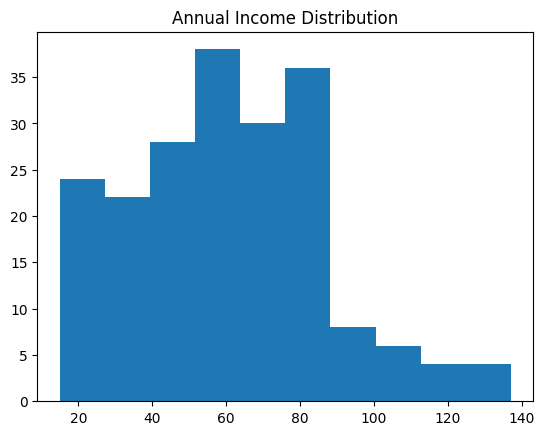

In [10]:
plt.hist(df["Annual Income (k$)"])

plt.title("Annual Income Distribution")

plt.show()

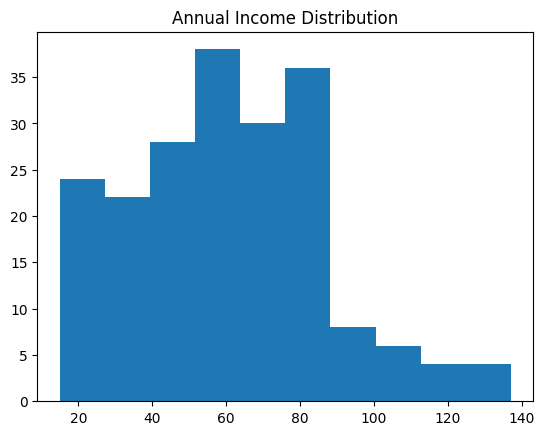

In [11]:
plt.hist(df["Annual Income (k$)"])

plt.title("Annual Income Distribution")

plt.show()

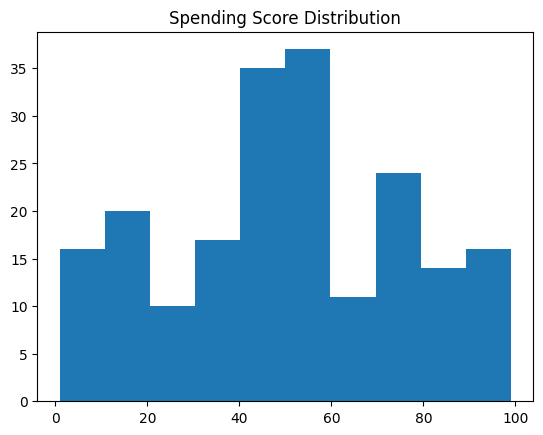

In [12]:
plt.hist(df["Spending Score (1-100)"])

plt.title("Spending Score Distribution")

plt.show()

In [13]:
X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

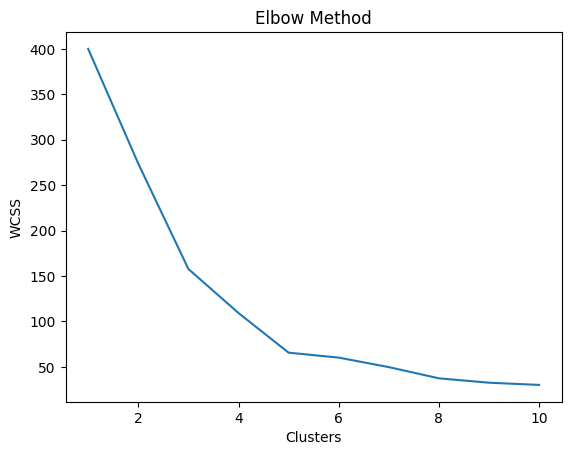

In [16]:
plt.plot(range(1,11), wcss)

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()

In [18]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(
    X_scaled
)

In [19]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


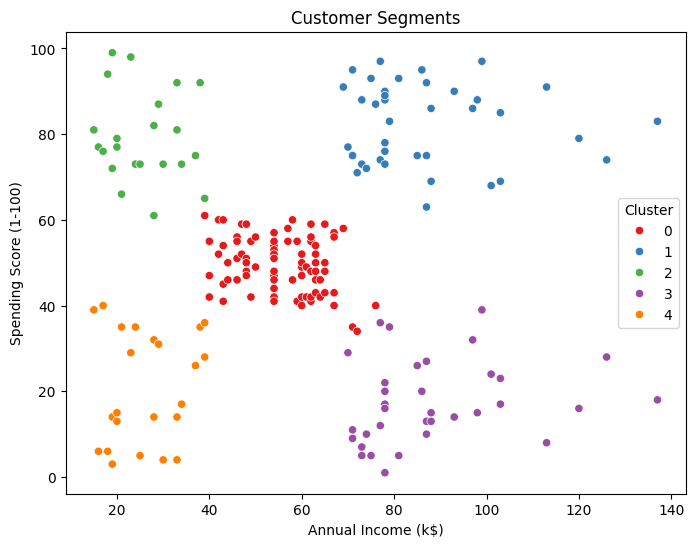

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    x="Annual Income (k$)",

    y="Spending Score (1-100)",

    hue="Cluster",

    data=df,

    palette="Set1"
)

plt.title("Customer Segments")

plt.show()

In [21]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_scaled
)

In [23]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = df["Cluster"]

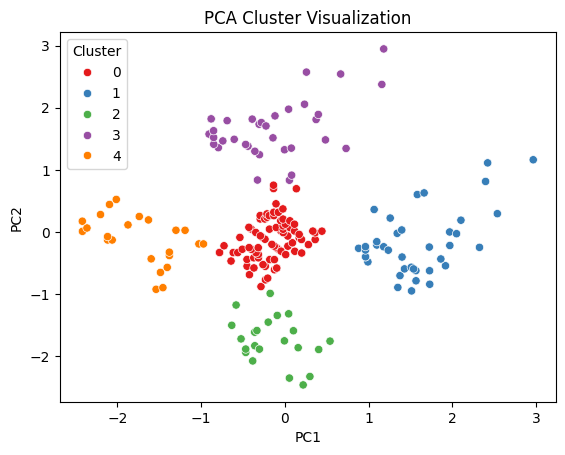

In [24]:
sns.scatterplot(

    x="PC1",

    y="PC2",

    hue="Cluster",

    data=pca_df,

    palette="Set1"
)

plt.title("PCA Cluster Visualization")

plt.show()

In [25]:
df.groupby("Cluster").mean(
    numeric_only=True
)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


## Marketing Strategies

Cluster 0:
High income, high spending customers.
Offer premium products and loyalty rewards.

Cluster 1:
Low income, low spending customers.
Provide discounts and promotional offers.

Cluster 2:
Young customers with high spending.
Target with social media campaigns.

Cluster 3:
Moderate income and spending.
Upsell products through personalized recommendations.

Cluster 4:
High income but low spending.
Encourage purchases with exclusive memberships.